In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

DATA_PATH = "NuclearPowerPlantAccidentData/Operation_csv_data"

# Ricarichiamo il normale
df_normal = pd.read_csv(os.path.join(DATA_PATH, "Normal", "1.csv"))

# Guardiamo la varianza di ogni feature (escludendo TIME)
variances = df_normal.drop(columns=["TIME"]).var().sort_values(ascending=False)
print(variances.head(20))

SGLK    2.246287e+08
RBLK    1.356016e+06
WFWB    2.240883e+05
WSTB    2.005636e+05
QMWT    1.212633e+05
WRCB    1.115597e+05
WFWA    5.600263e+04
QMGB    5.499598e+04
HTR     5.234454e+04
WSTA    5.012472e+04
WRCA    2.762381e+04
QMGA    1.374448e+04
TFPK    3.666480e+03
TF      3.666480e+03
TFSB    3.653672e+03
WRLB    3.021988e+03
TPCT    1.011602e+03
WRLA    7.554968e+02
WSPY    6.952882e+02
WECS    3.133358e+02
dtype: float64


In [4]:
print("\nFeature con varianza quasi zero:")
print(variances[variances < 1e-6])


Feature con varianza quasi zero:
RM2      8.622401e-07
DTHY     1.050154e-07
DWB      2.649338e-11
VOID     9.054447e-12
PRBA     1.236690e-32
RM3      1.932328e-34
RM4      4.830821e-35
MDBR     0.000000e+00
WLD      0.000000e+00
MBK      0.000000e+00
TDBR     0.000000e+00
EBK      0.000000e+00
PPM      0.000000e+00
TSLP     0.000000e+00
TCRT     0.000000e+00
MGAS     0.000000e+00
STTB     0.000000e+00
MCRT     0.000000e+00
TKLV     0.000000e+00
FRZR     0.000000e+00
QRHR     0.000000e+00
RM1      0.000000e+00
STRB     0.000000e+00
RC131    0.000000e+00
WTRB     0.000000e+00
FRCL     0.000000e+00
PRB      0.000000e+00
TRB      0.000000e+00
LWRB     0.000000e+00
QFCL     0.000000e+00
WBK      0.000000e+00
WTRA     0.000000e+00
WCSP     0.000000e+00
MH2      0.000000e+00
CNH2     0.000000e+00
RHBR     0.000000e+00
WHPI     0.000000e+00
WUP      0.000000e+00
WLR      0.000000e+00
WCFT     0.000000e+00
WLPI     0.000000e+00
LVCR     0.000000e+00
RC87     0.000000e+00
WFLB     0.000000e+0

In [5]:
# Rimuoviamo feature costanti o quasi costanti nel normale (varianza < 1)
features_to_drop = variances[variances < 1].index.tolist()
print(f"Feature rimosse: {len(features_to_drop)}")
print(features_to_drop)

# Feature rimanenti
features_kept = variances[variances >= 1].index.tolist()
print(f"\nFeature mantenute: {len(features_kept)}")
print(features_kept)

Feature rimosse: 55
['DNBR', 'RHRD', 'RHMT', 'LSGA', 'LSGB', 'RHFL', 'STSG', 'RRCB', 'RRCO', 'RRCA', 'RH', 'RM2', 'DTHY', 'DWB', 'VOID', 'PRBA', 'RM3', 'RM4', 'MDBR', 'WLD', 'MBK', 'TDBR', 'EBK', 'PPM', 'TSLP', 'TCRT', 'MGAS', 'STTB', 'MCRT', 'TKLV', 'FRZR', 'QRHR', 'RM1', 'STRB', 'RC131', 'WTRB', 'FRCL', 'PRB', 'TRB', 'LWRB', 'QFCL', 'WBK', 'WTRA', 'WCSP', 'MH2', 'CNH2', 'RHBR', 'WHPI', 'WUP', 'WLR', 'WCFT', 'WLPI', 'LVCR', 'RC87', 'WFLB']

Feature mantenute: 41
['SGLK', 'RBLK', 'WFWB', 'WSTB', 'QMWT', 'WRCB', 'WFWA', 'QMGB', 'HTR', 'WSTA', 'WRCA', 'QMGA', 'TFPK', 'TF', 'TFSB', 'WRLB', 'TPCT', 'WRLA', 'WSPY', 'WECS', 'WCHG', 'HLW', 'PWR', 'PWNT', 'TBLD', 'LVPZ', 'HUP', 'SCMB', 'SCMA', 'THB', 'THA', 'TAVG', 'VOL', 'P', 'TCA', 'TCB', 'PSGA', 'PSGB', 'NSGB', 'NSGA', 'TSAT']


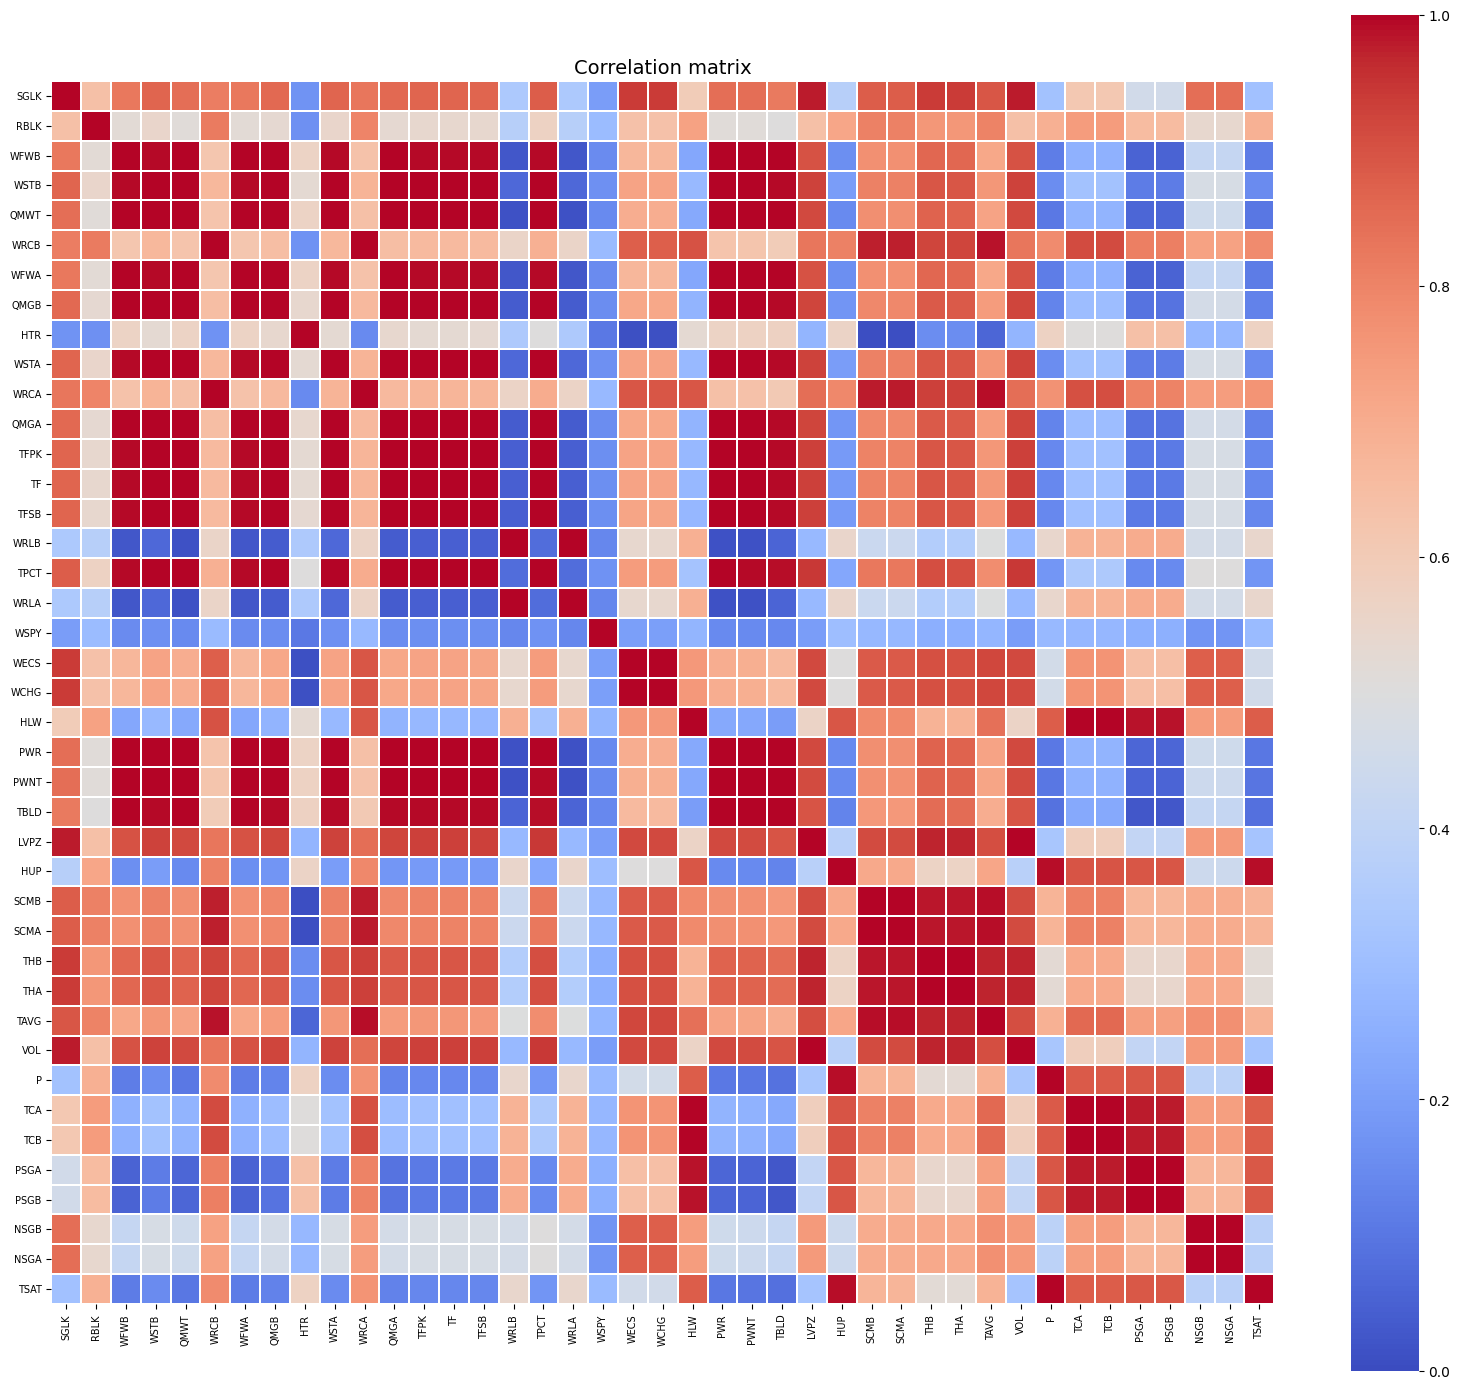

In [7]:
import seaborn as sns

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_matrix,
    annot=False,
    cmap="coolwarm",
    vmin=0, vmax=1,
    square=True,
    linewidths=0.3,
    xticklabels=features_kept,
    yticklabels=features_kept,
    ax=ax
)
plt.title("Correlation matrix", fontsize=14)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7, rotation=0)
plt.tight_layout()
plt.show()

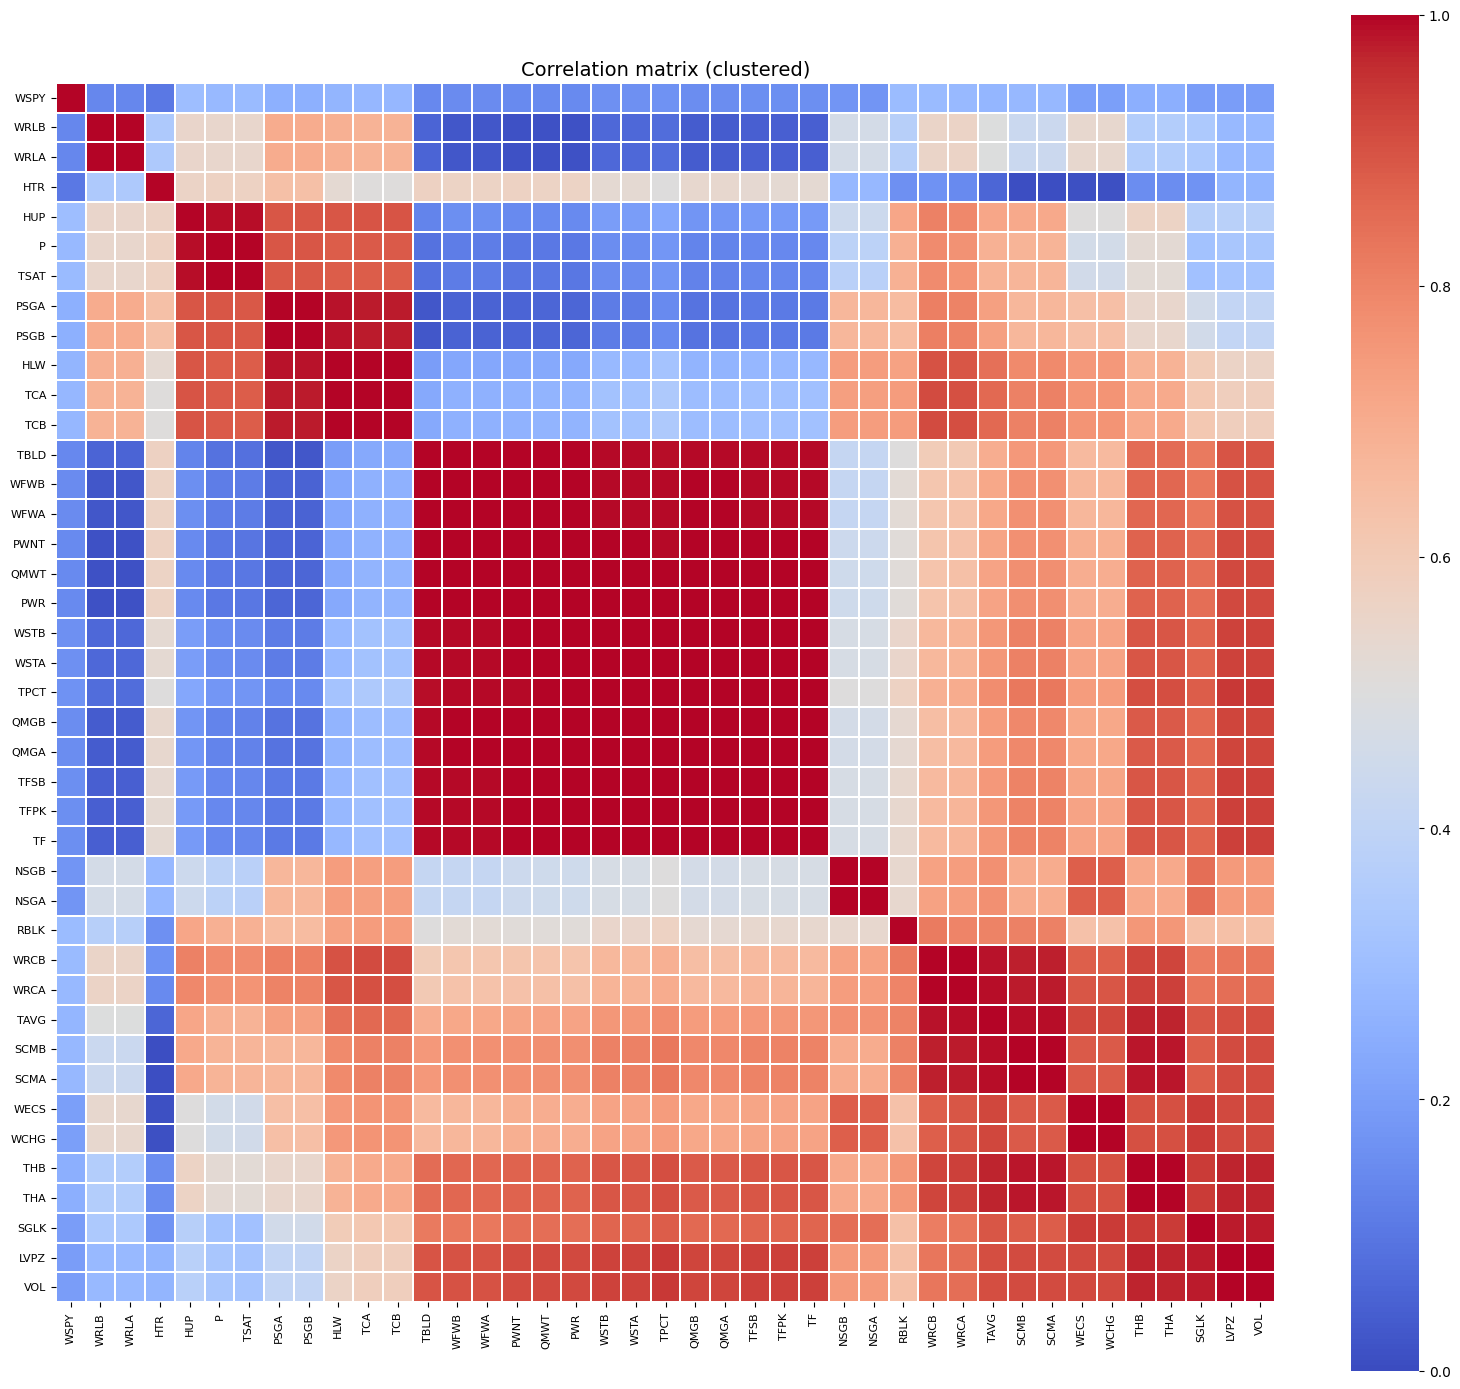

In [8]:
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform

# Clusterizziamo le feature per mettere vicine quelle correlate
distance_matrix = 1 - corr_matrix
condensed = squareform(distance_matrix, checks=False)
linkage = hierarchy.ward(condensed)
order = hierarchy.leaves_list(linkage)

# Riordiniamo la matrice
features_ordered = [features_kept[i] for i in order]
corr_reordered = corr_matrix.loc[features_ordered, features_ordered]

fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(
    corr_reordered,
    annot=False,
    cmap="coolwarm",
    vmin=0, vmax=1,
    square=True,
    linewidths=0.3,
    xticklabels=features_ordered,
    yticklabels=features_ordered,
    ax=ax
)
plt.title("Correlation matrix (clustered)", fontsize=14)
plt.xticks(fontsize=8, rotation=90)
plt.yticks(fontsize=8, rotation=0)
plt.tight_layout()
plt.show()

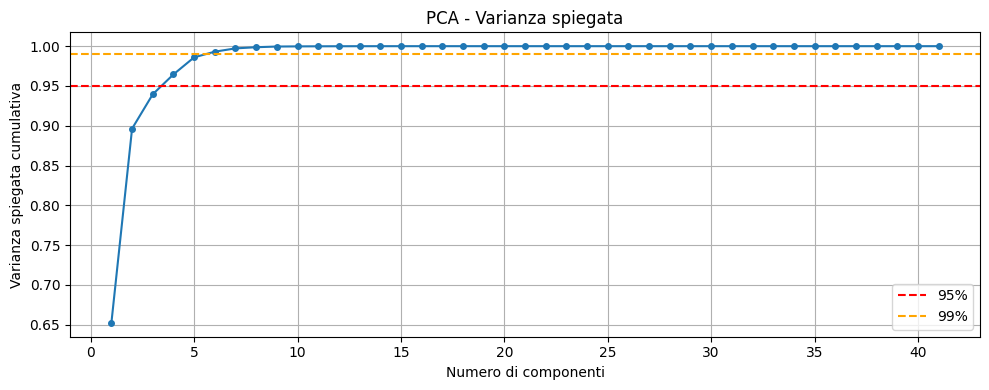

Componenti per 95% varianza: 4
Componenti per 99% varianza: 6


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prendiamo solo le feature selezionate, senza TIME
X_normal = df_normal[features_kept].values

# Normalizziamo (fondamentale prima della PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_normal)

# PCA per vedere quanta varianza spiegano le componenti
pca_full = PCA()
pca_full.fit(X_scaled)

# Varianza cumulativa
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', markersize=4)
plt.axhline(y=0.95, color='red', linestyle='--', label='95%')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99%')
plt.xlabel("Numero di componenti")
plt.ylabel("Varianza spiegata cumulativa")
plt.title("PCA - Varianza spiegata")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Quante componenti servono?
n_95 = np.argmax(cumvar >= 0.95) + 1
n_99 = np.argmax(cumvar >= 0.99) + 1
print(f"Componenti per 95% varianza: {n_95}")
print(f"Componenti per 99% varianza: {n_99}")

Shape originale: (302, 41)
Shape dopo PCA: (302, 6)


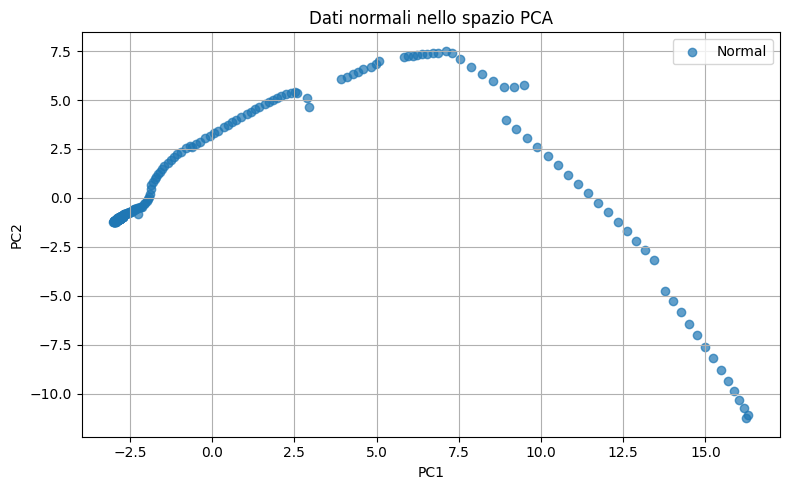

In [10]:
# Applichiamo PCA con 6 componenti
n_components = 6
pca = PCA(n_components=n_components)
X_pca = pca.fit_transform(X_scaled)

print(f"Shape originale: {X_scaled.shape}")
print(f"Shape dopo PCA: {X_pca.shape}")

# Visualizziamo le prime 2 componenti
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.7, label="Normal")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Dati normali nello spazio PCA")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

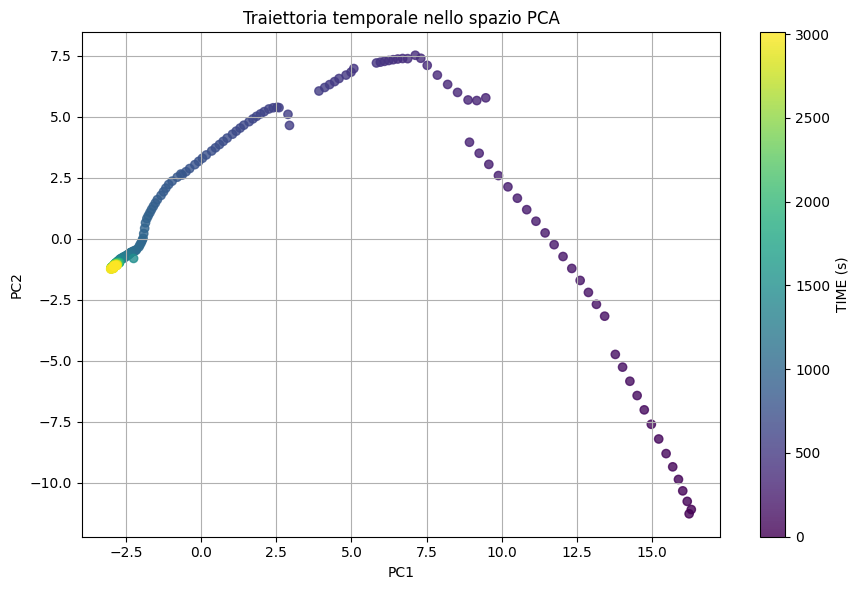

In [11]:
# Coloriamo i punti per timestep per vedere l'evoluzione temporale
plt.figure(figsize=(9, 6))
sc = plt.scatter(X_pca[:, 0], X_pca[:, 1], 
                 c=df_normal["TIME"], cmap="viridis", alpha=0.8)
plt.colorbar(sc, label="TIME (s)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Traiettoria temporale nello spazio PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
print(df_normal["TIME"].head(10))
print(df_normal["TIME"].tail(10))

0     0.0
1    10.0
2    20.0
3    30.0
4    40.0
5    50.0
6    60.0
7    70.0
8    80.0
9    90.0
Name: TIME, dtype: float64
292    2920.0
293    2930.0
294    2940.0
295    2950.0
296    2960.0
297    2970.0
298    2980.0
299    2990.0
300    3000.0
301    3010.0
Name: TIME, dtype: float64


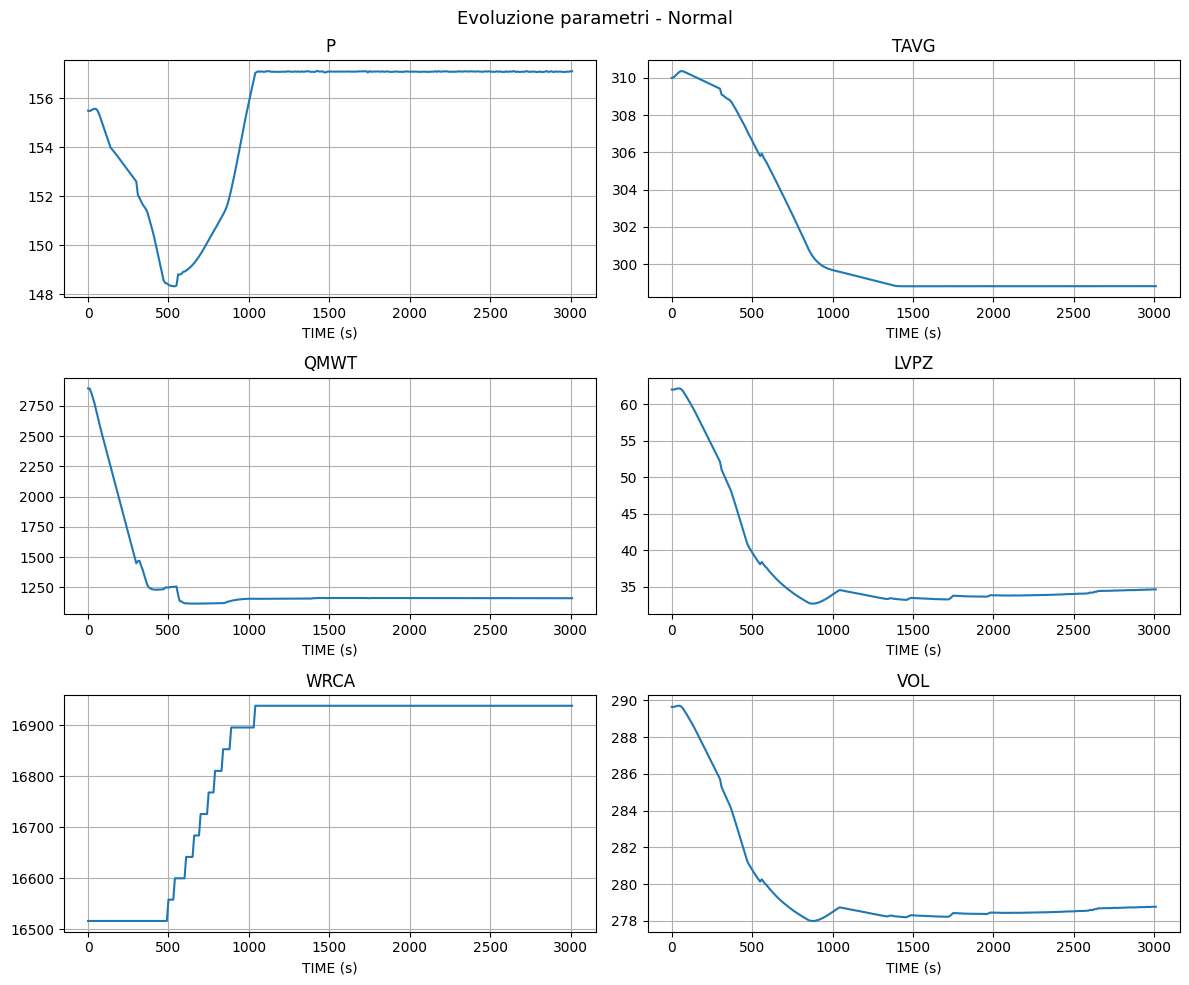

In [13]:
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
params_check = ["P", "TAVG", "QMWT", "LVPZ", "WRCA", "VOL"]

for ax, param in zip(axes.flatten(), params_check):
    ax.plot(df_normal["TIME"], df_normal[param])
    ax.set_title(param)
    ax.set_xlabel("TIME (s)")
    ax.grid(True)

plt.suptitle("Evoluzione parametri - Normal", fontsize=13)
plt.tight_layout()
plt.show()

Timestep totali: 302
Timestep steady state: 202


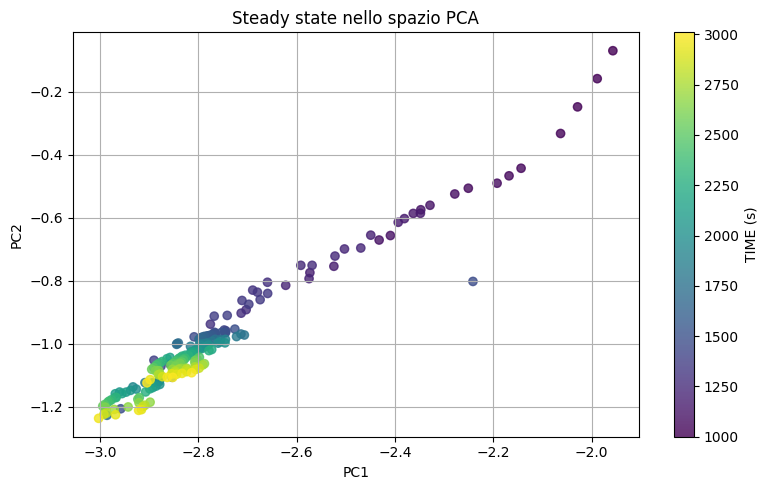

In [14]:
# Teniamo solo la parte stazionaria (da t=1000s in poi)
df_steady = df_normal[df_normal["TIME"] >= 1000].copy()
print(f"Timestep totali: {len(df_normal)}")
print(f"Timestep steady state: {len(df_steady)}")

# Rivisualizzziamo nello spazio PCA
X_steady = df_steady[features_kept].values
X_steady_scaled = scaler.transform(X_steady)
X_steady_pca = pca.transform(X_steady_scaled)

plt.figure(figsize=(8, 5))
sc = plt.scatter(X_steady_pca[:, 0], X_steady_pca[:, 1],
                 c=df_steady["TIME"], cmap="viridis", alpha=0.8)
plt.colorbar(sc, label="TIME (s)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Steady state nello spazio PCA")
plt.grid(True)
plt.tight_layout()
plt.show()

In [16]:
import pickle

# Salviamo scaler, pca e dati processati
preprocessing = {
    "scaler": scaler,
    "pca": pca,
    "features_kept": features_kept,
    "n_components": n_components,
    "steady_state_threshold": 1000,
    "X_train": X_steady_pca  # dati normali steady state nello spazio PCA
}

with open("preprocessing.pkl", "wb") as f:
    pickle.dump(preprocessing, f)

print("Preprocessing salvato.")
print(f"X_train shape: {X_steady_pca.shape}")

Preprocessing salvato.
X_train shape: (202, 6)
